In [2]:
# Установка дополнительных библиотек для работы с картами и геоданными.

!pip -q install folium
!pip -q install contextily
!pip -q install geopandas
!pip -q install shapely

In [3]:
# Импорт библиотек для анализа данных, визуализации, карт и построения регрессионных моделей.

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import folium
import geopandas as gpd
import contextily as ctx
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

In [4]:
# Настройка масштаба шрифтов для графиков seaborn.

sns.set(font_scale=1.3)

In [5]:
# Загрузка набора данных.

df = pd.read_csv('Real estate.csv')

display(df.head())

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## **Описательный анализ данных (EDA)**

### **Диаграммы признаков датасета**

In [6]:
# Преобразование даты сделки в удобный формат.

df["transaction_date"] = (
    pd.to_datetime(df["X1 transaction date"].astype(int).astype(str) + "-01-01")
    + pd.to_timedelta((df["X1 transaction date"] % 1) * 365.25, unit="D")
).dt.normalize()


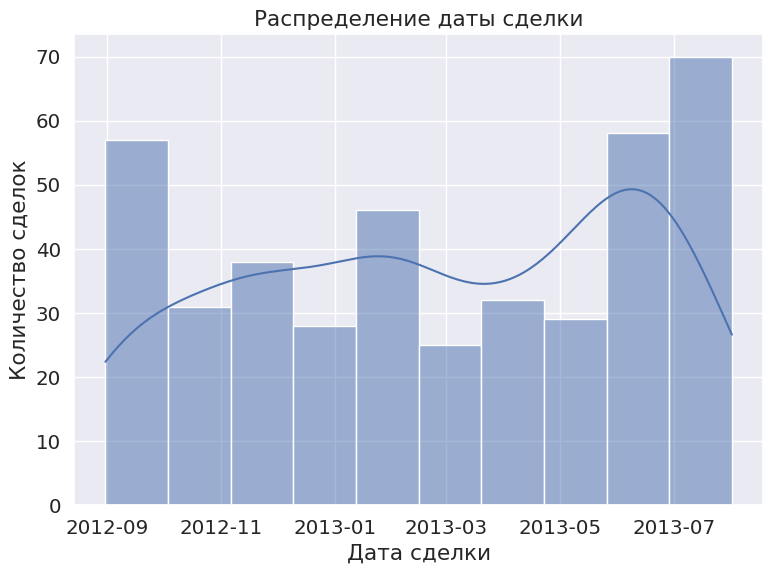

In [7]:
# Построение распределения дат.

plt.figure(figsize=(8, 6))
sns.histplot(df["transaction_date"], kde=True)
plt.title("Распределение даты сделки")
plt.xlabel("Дата сделки")
plt.ylabel("Количество сделок")
plt.tight_layout()
plt.show()

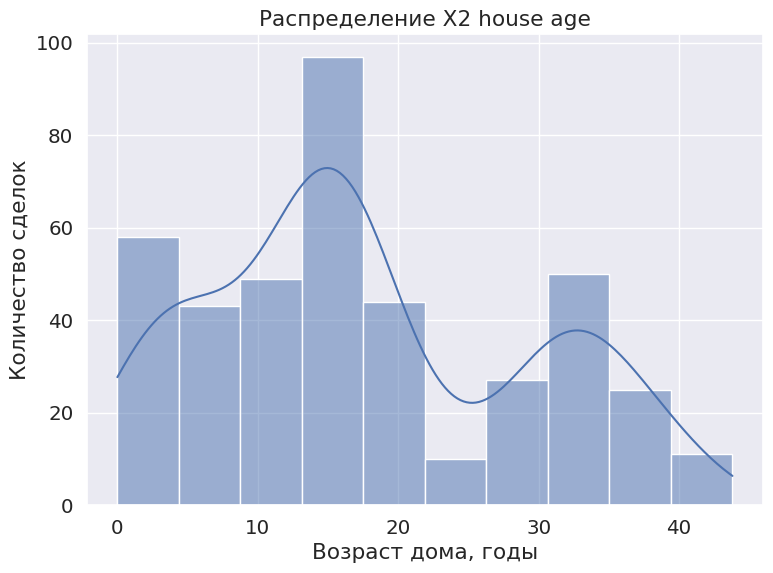

In [8]:
# Построение распределения возраста домов.

plt.figure(figsize=(8, 6))
sns.histplot(df['X2 house age'], kde=True)
plt.title('Распределение X2 house age')
plt.xlabel('Возраст дома, годы')
plt.ylabel('Количество сделок')
plt.tight_layout()
plt.show()

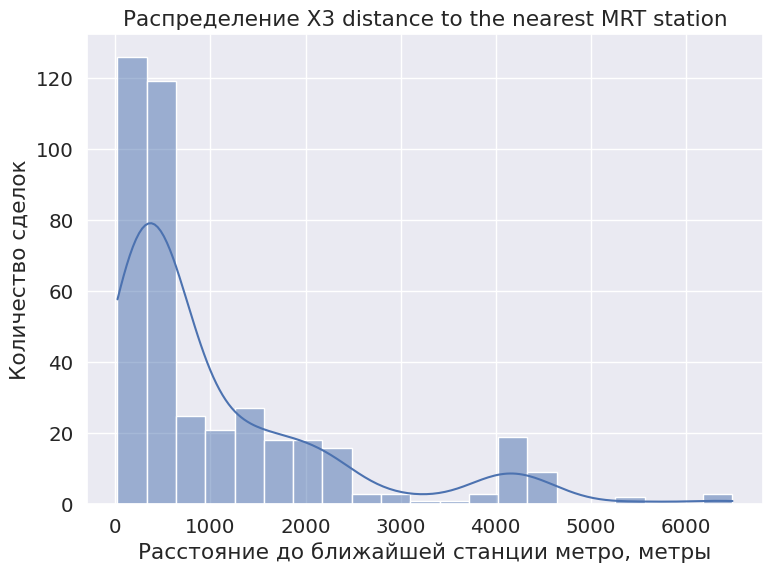

In [9]:
# Построение распределения расстояния до ближайшей станции метро.

plt.figure(figsize=(8, 6))
sns.histplot(df['X3 distance to the nearest MRT station'], kde=True)
plt.title('Распределение X3 distance to the nearest MRT station')
plt.xlabel('Расстояние до ближайшей станции метро, метры')
plt.ylabel('Количество сделок')
plt.tight_layout()
plt.show()

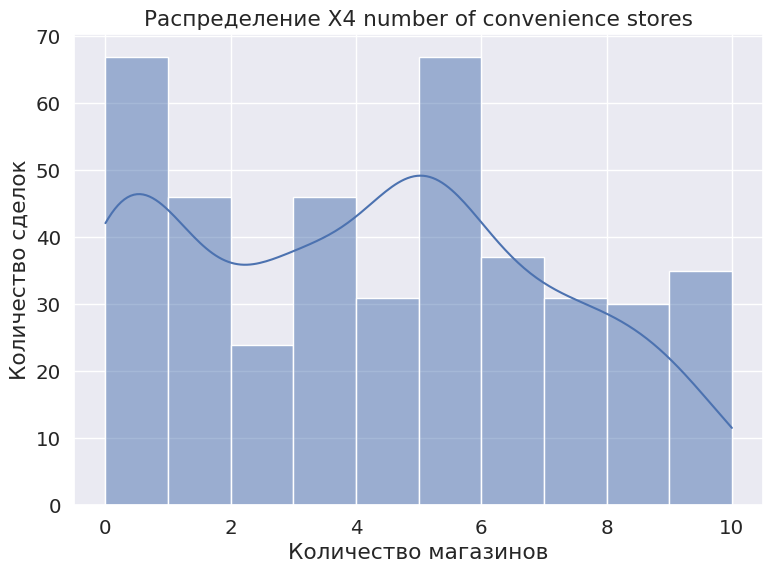

In [10]:
# Построение распределения количества магазинов рядом с объектом.

plt.figure(figsize=(8, 6))
sns.histplot(df['X4 number of convenience stores'], kde=True)
plt.title('Распределение X4 number of convenience stores')
plt.xlabel('Количество магазинов')
plt.ylabel('Количество сделок')
plt.tight_layout()
plt.show()

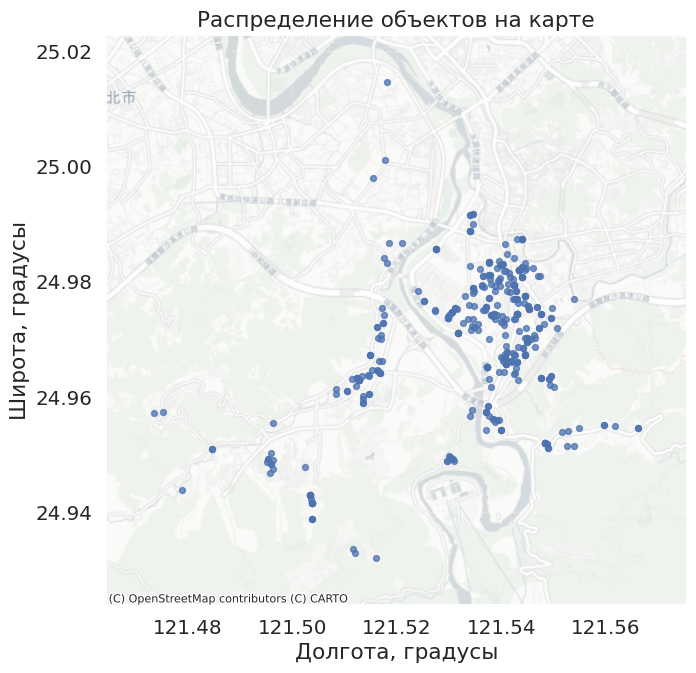

In [11]:
# Визуализация расположения объектов недвижимости на карте.

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X6 longitude"], df["X5 latitude"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(9, 7))

minx, miny, maxx, maxy = gdf.total_bounds
pad_x = (maxx - minx) * 0.10
pad_y = (maxy - miny) * 0.10
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326"
)

gdf.plot(ax=ax, markersize=18, alpha=0.75)

ax.set_title("Распределение объектов на карте")
ax.set_xlabel("Долгота, градусы")
ax.set_ylabel("Широта, градусы")

ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### **Графики относительно цены объекта**

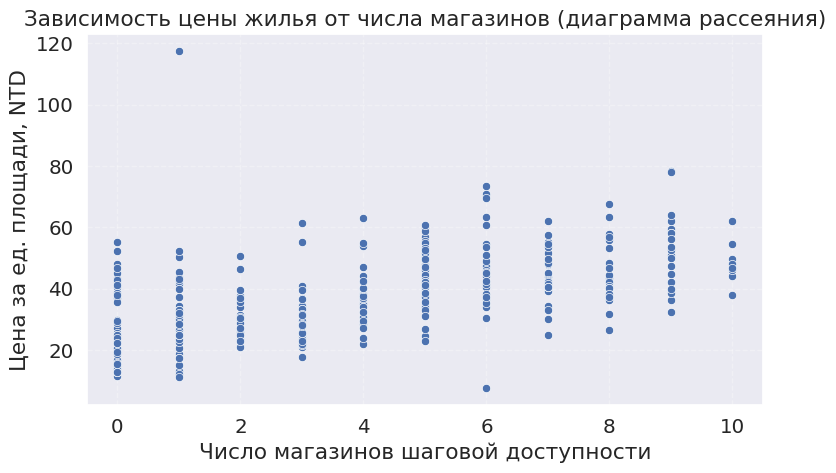

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [20]:
# Зависимость стоимости жилья от количества магазинов поблизости (диаграмма рассеяния).

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="X4 number of convenience stores",
    y="Y house price of unit area"
)

plt.title("Зависимость цены жилья от числа магазинов (диаграмма рассеяния)")
plt.xlabel("Число магазинов шаговой доступности")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))


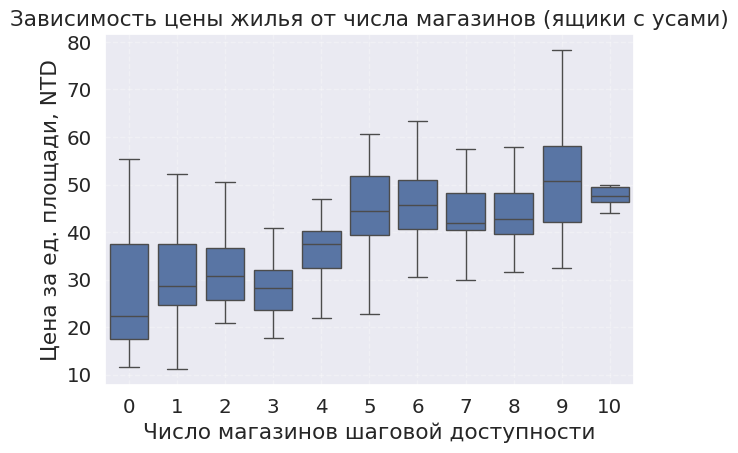

In [24]:
# Зависимость стоимости жилья от количества магазинов поблизости (ящик с усами).
sns.boxplot(
    data=df,
    x="X4 number of convenience stores",
    y="Y house price of unit area",
    order=range(0, 11),
    showfliers=False
)

plt.title("Зависимость цены жилья от числа магазинов (ящики с усами)")
plt.xlabel("Число магазинов шаговой доступности")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

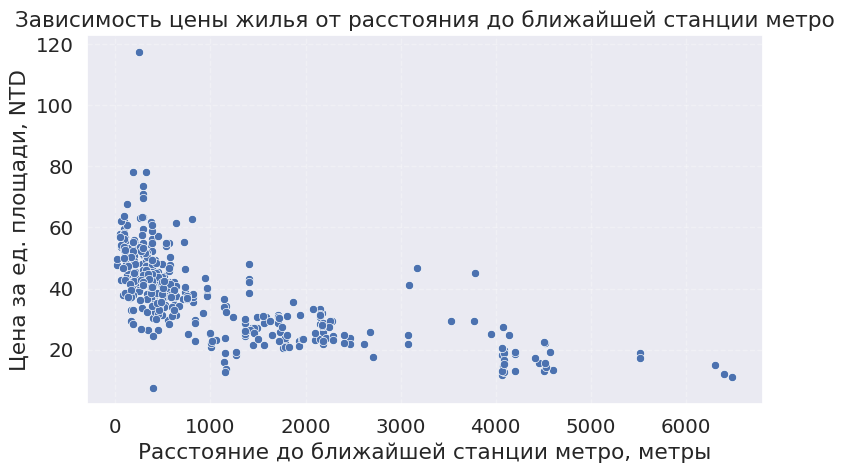

In [25]:
# Зависимость стоимости жилья от расстояния до ближайшей станции метро.

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="X3 distance to the nearest MRT station",
    y="Y house price of unit area"
)

plt.title("Зависимость цены жилья от расстояния до ближайшей станции метро")
plt.xlabel("Расстояние до ближайшей станции метро, метры")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()



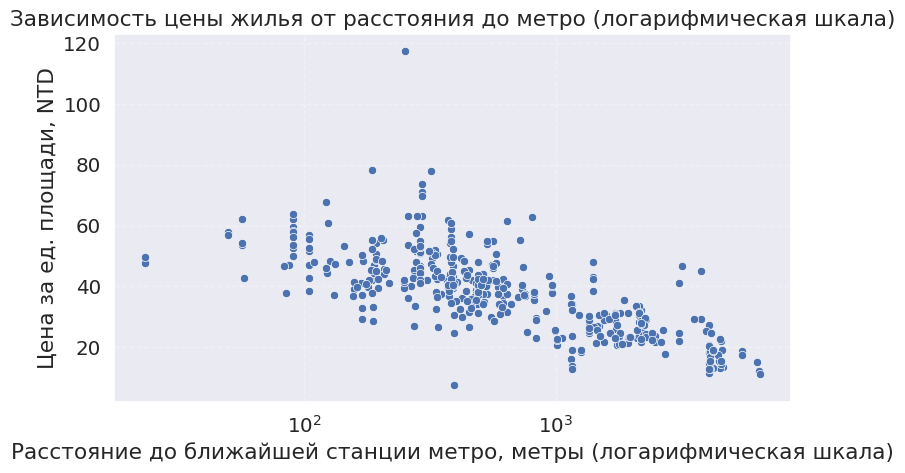

In [26]:
# Зависимость стоимости жилья от логарифмированного расстояния до ближайшей станции метро.
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="X3 distance to the nearest MRT station",
    y="Y house price of unit area"
)

plt.xscale("log")

plt.title("Зависимость цены жилья от расстояния до метро (логарифмическая шкала)")
plt.xlabel("Расстояние до ближайшей станции метро, метры (логарифмическая шкала)")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

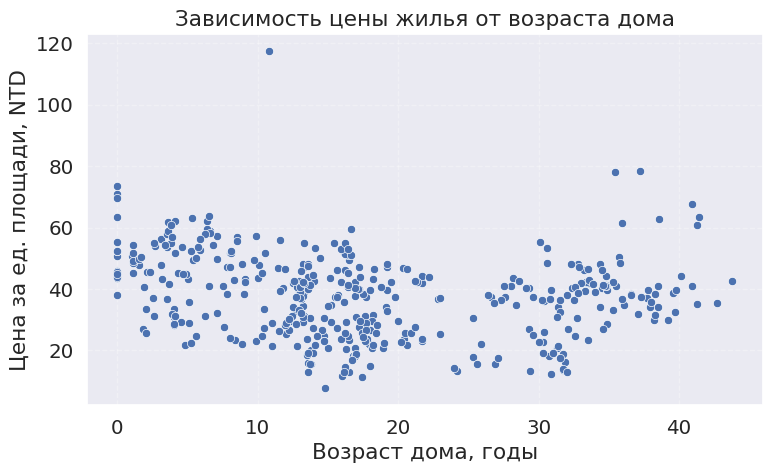

In [30]:
# Зависимость стоимости жилья от возраста дома.

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="X2 house age",
    y="Y house price of unit area"
)

plt.title("Зависимость цены жилья от возраста дома")
plt.xlabel("Возраст дома, годы")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

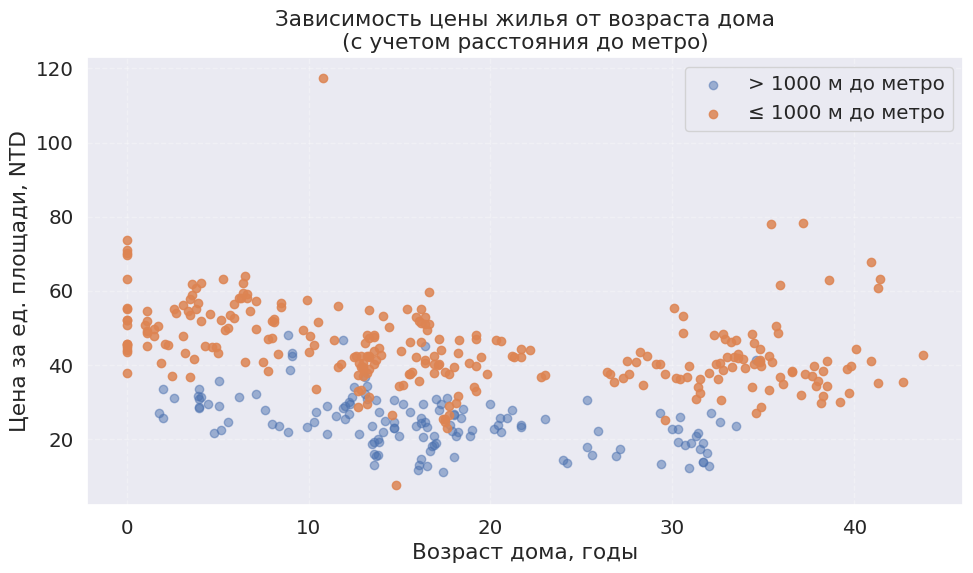

In [31]:
#  Зависимость стоимости жилья от возраста дома c учетом близости к метро.
thr = 1000

mask_near = df["X3 distance to the nearest MRT station"] <= thr
mask_far = ~mask_near

x_near = df.loc[mask_near, "X2 house age"]
y_near = df.loc[mask_near, "Y house price of unit area"]

x_far = df.loc[mask_far, "X2 house age"]
y_far = df.loc[mask_far, "Y house price of unit area"]

plt.figure(figsize=(10, 6))

plt.scatter(x_far, y_far, alpha=0.5, label=f"> {thr} м до метро")
plt.scatter(x_near, y_near, alpha=0.85, label=f"≤ {thr} м до метро")

plt.title("Зависимость цены жилья от возраста дома\n(с учетом расстояния до метро)")
plt.xlabel("Возраст дома, годы")
plt.ylabel("Цена за ед. площади, NTD")

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

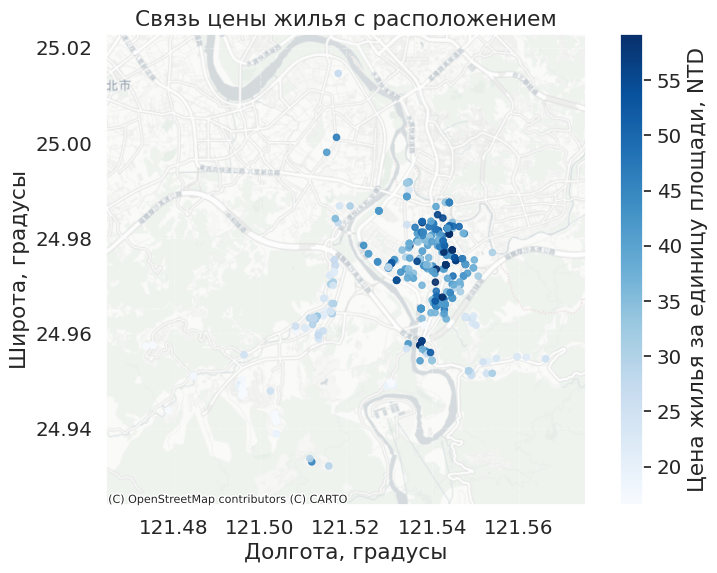

In [34]:
# Визуализация стоимости жилья на карте по географическому расположению объектов.

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X6 longitude"], df["X5 latitude"]),
    crs="EPSG:4326"
)

vmin = df["Y house price of unit area"].quantile(0.05)
vmax = df["Y house price of unit area"].quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 6))

minx, miny, maxx, maxy = gdf.total_bounds
pad_x = (maxx - minx) * 0.10
pad_y = (maxy - miny) * 0.10
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

gdf.plot(
    ax=ax,
    column="Y house price of unit area",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    alpha=0.9,
    markersize=20
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326"
)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = mpl.cm.ScalarMappable(cmap="Blues", norm=norm)
scalar_mappable.set_array([])
cbar = fig.colorbar(scalar_mappable, ax=ax)
cbar.set_label("Цена жилья за единицу площади, NTD")

ax.set_title("Связь цены жилья с расположением")
ax.set_xlabel("Долгота, градусы")
ax.set_ylabel("Широта, градусы")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## **Построение множественной линейной регрессии**

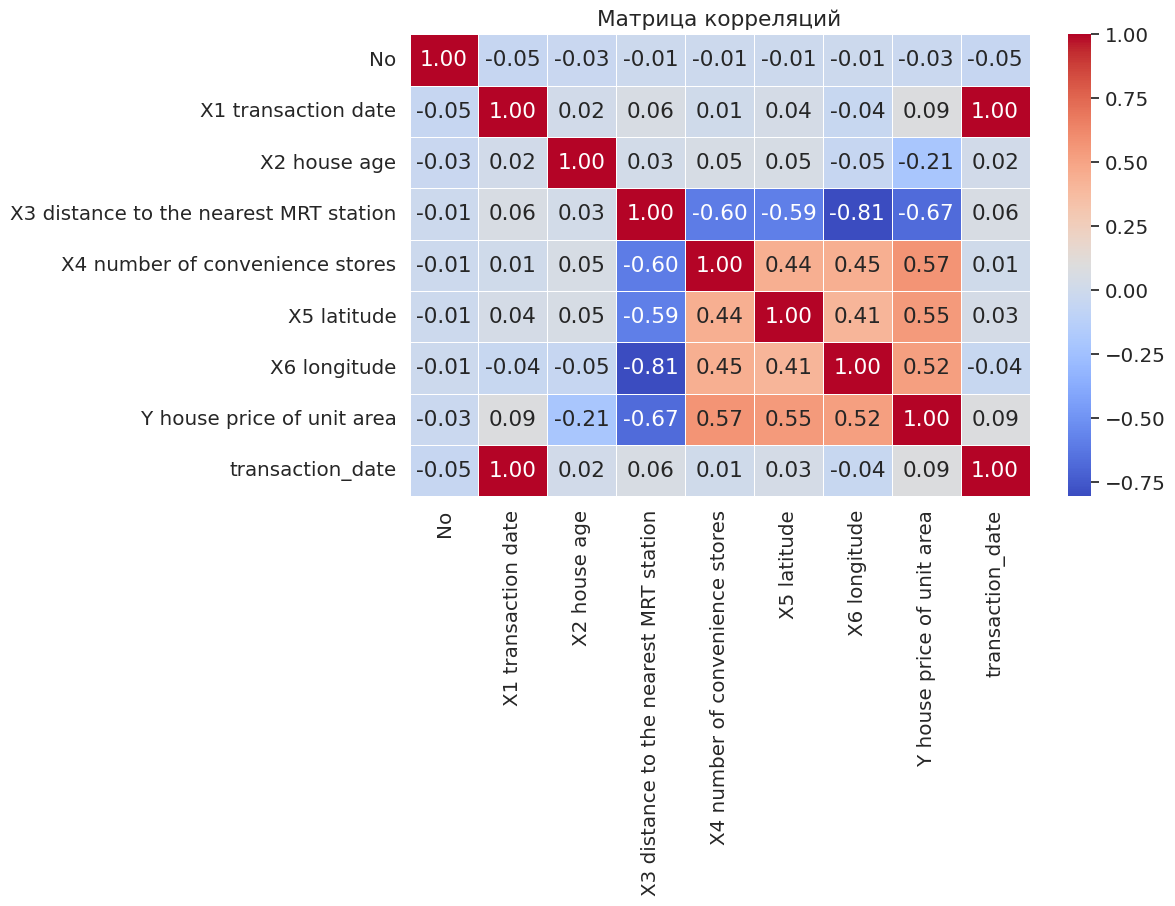

In [35]:
# Построение матрицы корреляций между признаками набора данных.

correlation_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матрица корреляций')
plt.show()

In [36]:
# Обучение базовой модели множественной линейной регрессии и оценка ее качества.

feature_cols = [
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude",
]

target_col = "Y house price of unit area"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=77
)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_train_pred = baseline_model.predict(X_train)
y_test_pred  = baseline_model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

print("=== Базовая модель множественной регрессии ===")
print(f"R² (train):   {r2_score(y_train, y_train_pred):.3f}")
print(f"R² (test):    {r2_score(y_test,  y_test_pred):.3f}")
print(f"RMSE (train): {rmse_train:.3f}")
print(f"RMSE (test):  {rmse_test:.3f}")


=== Базовая модель множественной регрессии ===
R² (train):   0.554
R² (test):    0.581
RMSE (train): 9.323
RMSE (test):  7.950


In [37]:
# Проверка статистической значимости признаков с помощью OLS-регрессии.

X = df[feature_cols]
y = df[target_col]

X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
pvals = ols_model.pvalues.to_frame(name="p_value")
print(pvals)


                                             p_value
const                                   4.263534e-01
X2 house age                            2.044371e-11
X3 distance to the nearest MRT station  8.166456e-09
X4 number of convenience stores         2.273810e-09
X5 latitude                             2.001707e-07
X6 longitude                            8.738953e-01


In [38]:
# Добавление признака центрального кластера и обучение улучшенной модели.

df["central_cluster"] = (df["X3 distance to the nearest MRT station"] <= 1000).astype(int)

feature_cols = [
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "central_cluster",
]

target_col = "Y house price of unit area"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=77
)

model_cluster = LinearRegression()
model_cluster.fit(X_train, y_train)

y_train_pred = model_cluster.predict(X_train)
y_test_pred  = model_cluster.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

print("=== Модель с добавлением признака кластеров ===")
print(f"R² (train):   {r2_score(y_train, y_train_pred):.3f}")
print(f"R² (test):    {r2_score(y_test,  y_test_pred):.3f}")
print(f"RMSE (train): {rmse_train:.3f}")
print(f"RMSE (test):  {rmse_test:.3f}")

=== Модель с добавлением признака кластеров ===
R² (train):   0.610
R² (test):    0.622
RMSE (train): 8.718
RMSE (test):  7.555


In [39]:
# Логарифмирование расстояния до метро и обучение модели с новым признаком.

df["log_mrt"] = np.log1p(df["X3 distance to the nearest MRT station"])

feature_cols = [
    "X2 house age",
    "log_mrt",
    "X4 number of convenience stores",
    "X5 latitude",
    "central_cluster",
]

target_col = "Y house price of unit area"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=77
)

model_cluster_log = LinearRegression()
model_cluster_log.fit(X_train, y_train)

y_train_pred = model_cluster_log.predict(X_train)
y_test_pred  = model_cluster_log.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

print("=== Модель с логарифмированным расстоянием до метро и признаком кластеров ===")
print(f"R² (train):   {r2_score(y_train, y_train_pred):.3f}")
print(f"R² (test):    {r2_score(y_test,  y_test_pred):.3f}")
print(f"RMSE (train): {rmse_train:.3f}")
print(f"RMSE (test):  {rmse_test:.3f}")

=== Модель с логарифмированным расстоянием до метро и признаком кластеров ===
R² (train):   0.640
R² (test):    0.639
RMSE (train): 8.379
RMSE (test):  7.377


In [41]:
# Обучение итоговой модели с учетом логарифмированного расстояния, кластера и квадрата возраста дома.

df["house_age_sq"] = df["X2 house age"] ** 2

feature_cols = [
    "X2 house age",
    "log_mrt",
    "X4 number of convenience stores",
    "X5 latitude",
    "central_cluster",
    "house_age_sq"
]

target_col = "Y house price of unit area"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=77
)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print("=== Итоговая модель с квадратом возраста дома ===")
print("Признаки:", feature_cols)
print(f"R² (train):   {r2_score(y_train, y_train_pred):.3f}")
print(f"R² (test):    {r2_score(y_test, y_test_pred):.3f}")
print(f"RMSE (train): {rmse_train:.3f}")
print(f"RMSE (test):  {rmse_test:.3f}")

=== Итоговая модель с квадратом возраста дома ===
Признаки: ['X2 house age', 'log_mrt', 'X4 number of convenience stores', 'X5 latitude', 'central_cluster', 'house_age_sq']
R² (train):   0.658
R² (test):    0.662
RMSE (train): 8.165
RMSE (test):  7.141
